In [656]:
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance
from scipy.stats import pearsonr
from scipy.signal import find_peaks
from scipy.special import factorial
from collections import defaultdict
import matplotlib.pyplot as plt

from run_experiments_best_params import build_model_configs, EXCLUDE_MODELS
from data import prepare_data, make_dataloader
from train_utils import set_seed, evaluate_model

#BASE_DIR = Path(__file__).resolve().parent
BASE_DIR = Path('.')
DATA_PATH = BASE_DIR / "synthetic+real_dataset_filtered_numpeaks.parquet"
EMBEDDING_PATH = BASE_DIR / "../modular_setup_improved/all_fm-rna_embeddings_filtered.pt"
BIN_EDGES_PATH = BASE_DIR / "bin_edges.npy"
CHECKPOINT_DIR = BASE_DIR / "checkpoints"
OUTPUT_CSV = BASE_DIR / "expressiveness.csv"

BIN_EDGES = np.load(BIN_EDGES_PATH)/np.log(10)
BIN_CENTERS = 0.5*(BIN_EDGES[1:] + BIN_EDGES[:-1])

SEED = 42
N_BINS = 50
DEVICE = "cpu"
VERSION_SUFFIX = "best_params_20ep"

# MODEL_ORDER = [
#     "glm_baseline",
#     "mean_pool_mlp",
#     "all_local_mlp",
#     "lstm",
#     "lstm_rna_fm",
#     "struct_lstm_rna_fm",
#     "transformer_rna_fm",
#     "loc_rna_fm",
# ]

MODEL_ORDER = [
    "naive_baseline",
    "length_baseline",
    "glm_baseline",
    "mean_pool_mlp",
    "all_local_mlp",
    "bilstm",
    "lstm_rna_fm",
    "struct_lstm_rna_fm",
    "transformer_rna_fm",
    "loc_rna_fm",
]

def js_dist(targets, preds):
    return np.array([jensenshannon(t, p) for t, p in zip(targets, preds)])

def wasserstein_dist(bin_centers, targets, preds):
    return np.array([wasserstein_distance(bin_centers, bin_centers, t, p) for t, p in zip(targets, preds)])

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def run_one_model(name, embeddings_dict):
    is_glm = (name == "glm_baseline")
    all_local_data = (name == "all_local_mlp")
    if is_glm:
        handpicked_cols = [
            "mfe", "n_local_minima", "gc_content",
            "freq_A", "freq_U", "freq_G", "freq_C",
            "freq_AA", "freq_AU", "freq_AG", "freq_AC",
            "freq_UA", "freq_UU", "freq_UG", "freq_UC",
            "freq_GA", "freq_GU", "freq_GG", "freq_GC",
            "freq_CA", "freq_CU", "freq_CG", "freq_CC",
        ]
    else:
        handpicked_cols = ["gc_content", "mfe", "n_local_minima"]

    set_seed(SEED)
    data = prepare_data(
        DATA_PATH, n_bins=N_BINS, random_state=SEED, handpicked_cols=handpicked_cols,
        bin_edges_path=BIN_EDGES_PATH, data_mask=None,
        local_minima_k=10 if all_local_data else None,
    )
    static_dim = data.train.static_features.shape[1]
    output_dim = data.train.targets.shape[1]

    train_targets = data.train.targets
    # val_targets = data.val.targets
    test_targets = data.test.targets

    # ---- naive_baseline: always predict the training marginal ------------
    if name == "naive_baseline":
        mean_train = train_targets.mean(axis=0)

        # train_pred = np.tile(mean_train, (len(train_targets), 1))
        # val_pred = np.tile(mean_train, (len(val_targets), 1))
        test_pred = np.tile(mean_train, (len(test_targets), 1))

        # naive_train_loss = kl_div(train_targets, train_pred).mean()
        # naive_val_loss = kl_div(val_targets, val_pred).mean()
        # naive_test_kl = kl_div(test_targets, test_pred).mean()
        naive_test_js = js_dist(test_targets, test_pred)
        js_scores = naive_test_js
        eval_result = {
            "preds": test_pred,
            "targets": test_targets,
            "js_scores": js_scores,
            "js_mean": float(np.mean(js_scores)),
            "js_median": float(np.median(js_scores)),
            "num_params": 0,
        }

    # ---- length_baseline: predict the mean target for that sequence length
    elif name == "length_baseline":
        mean_train = train_targets.mean(axis=0)

        train_lengths = np.array([len(s) for s in data.train.sequences])
        val_lengths = np.array([len(s) for s in data.val.sequences])
        test_lengths = np.array([len(s) for s in data.test.sequences])

        length_means = defaultdict(list)
        for length, target in zip(train_lengths, train_targets):
            length_means[int(length)].append(target)
        length_means = {length: np.mean(np.stack(vals), axis=0) for length, vals in length_means.items()}
        n_length_groups = len(length_means)

        def predict_for_lengths(lengths):
            return np.stack([length_means.get(int(l), mean_train) for l in lengths])

        # train_pred = predict_for_lengths(train_lengths)
        # val_pred = predict_for_lengths(val_lengths)
        test_pred = predict_for_lengths(test_lengths)

        # length_train_loss = kl_div(train_targets, train_pred).mean()
        # length_val_loss = kl_div(val_targets, val_pred).mean()
        # length_test_kl = kl_div(test_targets, test_pred).mean()
        length_test_js = js_dist(test_targets, test_pred)
        js_scores = length_test_js
        eval_result = {
            "preds": test_pred,
            "targets": test_targets,
            "js_scores": js_scores,
            "js_mean": float(np.mean(js_scores)),
            "js_median": float(np.median(js_scores)),
            "num_params": 0,
        }
    
    else:
        model_configs = build_model_configs(static_dim, output_dim)
        model = model_configs[name]["build"]().to(DEVICE)

        checkpoint_path = CHECKPOINT_DIR / f"best_{name}_{VERSION_SUFFIX}.pth"
        test_loader = make_dataloader(
            data.test, batching=model.BATCHING, batch_size=64,
            shuffle=False, embedding_dict=embeddings_dict,
        )

        eval_result = evaluate_model(model, test_loader, device=DEVICE, checkpoint_path=checkpoint_path)
        eval_result['num_params'] = count_parameters(model)
    
    # bin_edges = np.load(BIN_EDGES_PATH)
    # bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])
    eval_result['wasserstein_scores'] = wasserstein_dist(BIN_CENTERS, eval_result['targets'], eval_result['preds'])
    eval_result['wasserstein_mean'] = float(np.mean(eval_result['wasserstein_scores']))
    eval_result['wasserstein_median'] = float(np.median(eval_result['wasserstein_scores']))

    eps = 1e-8
    safe_preds = np.clip(eval_result['preds'], eps, None)
    safe_preds = safe_preds / safe_preds.sum(axis=-1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        kl_terms = np.where(
            eval_result['targets'] > 0, eval_result['targets'] * (np.log(eval_result['targets']) - np.log(safe_preds)), 0.0
        )
    kl_scores = kl_terms.sum(axis=-1)
    eval_result['kl_scores'] = kl_scores
    eval_result['kl_mean'] = float(np.mean(kl_scores))
    eval_result['kl_median'] = float(np.median(kl_scores))

    return eval_result

In [657]:
print(f"Loading RNA-FM embedding dictionary from {EMBEDDING_PATH}...")
embeddings_dict = torch.load(EMBEDDING_PATH)

Loading RNA-FM embedding dictionary from ..\modular_setup_improved\all_fm-rna_embeddings_filtered.pt...


In [658]:
# need to get run_one_model to work on "naive_baseline" and "length_baseline" too
# done!

In [659]:
eval_results = {}

for name in MODEL_ORDER:
    # if name in EXCLUDE_MODELS:
    #     continue
    eval_result = run_one_model(name, embeddings_dict)
    eval_results[name] = eval_result

    print(name, eval_result['num_params'], eval_result['js_mean'], eval_result['wasserstein_mean'])

naive_baseline 0 0.4764210879802704 1.545192734520542
length_baseline 0 0.36082085967063904 0.7868274269854665
glm_baseline 1200 0.3537447154521942 0.7486109619375702
mean_pool_mlp 3954 0.2824494242668152 0.5347655751512237
all_local_mlp 9586 0.28455865383148193 0.5272500244196654
bilstm 49074 0.2572843134403229 0.4459350992365225
lstm_rna_fm 373170 0.29845184087753296 0.5683351083231617
struct_lstm_rna_fm 374706 0.2620886266231537 0.46181770816367107
transformer_rna_fm 94898 0.3237435221672058 0.6338409663619047
loc_rna_fm 1792818 0.32299551367759705 0.638370702584419


# Make results table with wasserstein

In [725]:
df1 = pd.read_csv('cross_val_results/cross_val_final_with_test.csv')
df2 = pd.read_csv('expressiveness.csv')

In [726]:
df1

,cross_val_kl,test_kl,test_js,model
0,0.5154 +/- 0.0077,0.5205,0.3537,glm_baseline
1,0.3541 +/- 0.0067,0.3426,0.2824,mean_pool_mlp
2,0.3558 +/- 0.0076,0.3505,0.2846,all_local_mlp
3,0.3219 +/- 0.0116,0.3115,0.2660,lstm
4,0.4212 +/- 0.0047,0.3933,0.2985,lstm_rna_fm
5,0.3367 +/- 0.0063,0.3196,0.2621,struct_lstm_rna_fm
6,0.4484 +/- 0.0052,0.4537,0.3229,transformer_rna_fm
7,0.4503 +/- 0.0056,0.4625,0.3230,loc_rna_fm
8,0.9112 +/- 0.0165,0.9397,0.4764,naive_baseline
9,0.3121 +/- 0.0082,0.2995,0.2573,bilstm


In [727]:
df2

,model,pred_diversity,true_diversity,expressiveness_ratio,calibration
0,glm_baseline,0.314800,0.478000,0.658600,0.020100
1,mean_pool_mlp,0.375900,0.478000,0.786400,0.024400
2,all_local_mlp,0.388400,0.478000,0.812600,0.028800
3,lstm,0.386600,0.478000,0.808800,0.037400
4,bilstm,0.400600,0.478000,0.838100,0.034900
5,lstm_rna_fm,0.380000,0.478000,0.794900,0.023700
6,struct_lstm_rna_fm,0.395200,0.478000,0.826900,0.034600
7,transformer_rna_fm,0.375600,0.478000,0.785900,0.030200
8,loc_rna_fm,0.363000,0.478000,0.759300,0.027100
9,naive_baseline,0.000000,0.477991,0.000000,0.022583


In [728]:
df = pd.merge(df1, df2, on='model')
df = df[['model', 'expressiveness_ratio', 'calibration', 'cross_val_kl', 'test_kl', 'test_js']]
df = df[df['model']!='lstm']

MODEL_ORDER_DICT = {}
for i in range(len(MODEL_ORDER)):
    MODEL_ORDER_DICT[MODEL_ORDER[i]] = i
def MODEL_ORDER_FUNC(model):
    return MODEL_ORDER_DICT[model]

df = df.sort_values(by='model', key=np.vectorize(MODEL_ORDER_FUNC))

list_test_w1 = []
for model in MODEL_ORDER:
    list_test_w1.append(eval_results[model]['wasserstein_mean'])

df['test_w1'] = list_test_w1
df = df.round(4)

In [729]:
df

,model,expressiveness_ratio,calibration,cross_val_kl,test_kl,test_js,test_w1
8,naive_baseline,0.0000,0.0226,0.9112 +/- 0.0165,0.9397,0.4764,1.5452
10,length_baseline,0.6703,0.0162,0.5607 +/- 0.0142,0.5784,0.3608,0.7868
0,glm_baseline,0.6586,0.0201,0.5154 +/- 0.0077,0.5205,0.3537,0.7486
1,mean_pool_mlp,0.7864,0.0244,0.3541 +/- 0.0067,0.3426,0.2824,0.5348
2,all_local_mlp,0.8126,0.0288,0.3558 +/- 0.0076,0.3505,0.2846,0.5273
9,bilstm,0.8381,0.0349,0.3121 +/- 0.0082,0.2995,0.2573,0.4459
4,lstm_rna_fm,0.7949,0.0237,0.4212 +/- 0.0047,0.3933,0.2985,0.5683
5,struct_lstm_rna_fm,0.8269,0.0346,0.3367 +/- 0.0063,0.3196,0.2621,0.4618
6,transformer_rna_fm,0.7859,0.0302,0.4484 +/- 0.0052,0.4537,0.3229,0.6338
7,loc_rna_fm,0.7593,0.0271,0.4503 +/- 0.0056,0.4625,0.3230,0.6384


In [730]:
table_string = df.to_latex(index=False)

table_string = table_string.replace('expressiveness_ratio', 'expr')
table_string = table_string.replace('calibration', 'calib')
table_string = table_string.replace('_', r'\_')
table_string = table_string.replace('+/-', r'$\pm$')
table_string = table_string.replace('0.', '.')
table_string = table_string.replace('00 ', ' ')

In [731]:
print(table_string)

\begin{tabular}{lrrlrrr}
\toprule
model & expr & calib & cross\_val\_kl & test\_kl & test\_js & test\_w1 \\
\midrule
naive\_baseline & .0000 & .0226 & .9112 $\pm$ .0165 & .9397 & .4764 & 1.5452 \\
length\_baseline & .6703 & .0162 & .5607 $\pm$ .0142 & .5784 & .3608 & .7868 \\
glm\_baseline & .6586 & .0201 & .5154 $\pm$ .0077 & .5205 & .3537 & .7486 \\
mean\_pool\_mlp & .7864 & .0244 & .3541 $\pm$ .0067 & .3426 & .2824 & .5348 \\
all\_local\_mlp & .8126 & .0288 & .3558 $\pm$ .0076 & .3505 & .2846 & .5273 \\
bilstm & .8381 & .0349 & .3121 $\pm$ .0082 & .2995 & .2573 & .4459 \\
lstm\_rna\_fm & .7949 & .0237 & .4212 $\pm$ .0047 & .3933 & .2985 & .5683 \\
struct\_lstm\_rna\_fm & .8269 & .0346 & .3367 $\pm$ .0063 & .3196 & .2621 & .4618 \\
transformer\_rna\_fm & .7859 & .0302 & .4484 $\pm$ .0052 & .4537 & .3229 & .6338 \\
loc\_rna\_fm & .7593 & .0271 & .4503 $\pm$ .0056 & .4625 & .3230 & .6384 \\
\bottomrule
\end{tabular}



In [332]:
print(np.argsort(np.array(df['test_kl'])))
print(np.argsort(np.array(df['test_js'])))
print(np.argsort(np.array(df['test_w1'])))

[5 7 3 4 6 8 9 2 1 0]
[5 7 3 4 6 8 9 2 1 0]
[5 7 4 3 6 8 9 2 1 0]


In [745]:
df = pd.merge(df1, df2, on='model')
df = df[['model', 'cross_val_kl', 'test_kl', 'test_js', 'expressiveness_ratio']]
df = df[df['model']!='lstm']

MODEL_ORDER_DICT = {}
for i in range(len(MODEL_ORDER)):
    MODEL_ORDER_DICT[MODEL_ORDER[i]] = i
def MODEL_ORDER_FUNC(model):
    return MODEL_ORDER_DICT[model]

df = df.sort_values(by='model', key=np.vectorize(MODEL_ORDER_FUNC))

list_test_w1 = []
for model in MODEL_ORDER:
    list_test_w1.append(eval_results[model]['wasserstein_mean'])

list_median_corr = []
for model in MODEL_ORDER:
    list_median_corr.append(eval_results[model]['median_corr'])

df['test_w1'] = list_test_w1
df['median_corr'] = list_median_corr

df = df[['model', 'cross_val_kl', 'test_kl', 'test_js', 'test_w1', 'median_corr', 'expressiveness_ratio']]

df = df.round(4)

In [746]:
table_string = df.to_latex(index=False)

table_string = table_string.replace('expressiveness_ratio', 'expr')
table_string = table_string.replace('calibration', 'calib')
table_string = table_string.replace('_', r'\_')
table_string = table_string.replace('+/-', r'$\pm$')
table_string = table_string.replace('0.', '.')
table_string = table_string.replace('00 ', ' ')
table_string = table_string.replace('NaN', '-')

print(table_string)

\begin{tabular}{llrrrrr}
\toprule
model & cross\_val\_kl & test\_kl & test\_js & test\_w1 & median\_corr & expr \\
\midrule
naive\_baseline & .9112 $\pm$ .0165 & .9397 & .4764 & 1.5452 & - & .0000 \\
length\_baseline & .5607 $\pm$ .0142 & .5784 & .3608 & .7868 & .8245 & .6703 \\
glm\_baseline & .5154 $\pm$ .0077 & .5205 & .3537 & .7486 & .8648 & .6586 \\
mean\_pool\_mlp & .3541 $\pm$ .0067 & .3426 & .2824 & .5348 & .9033 & .7864 \\
all\_local\_mlp & .3558 $\pm$ .0076 & .3505 & .2846 & .5273 & .9063 & .8126 \\
bilstm & .3121 $\pm$ .0082 & .2995 & .2573 & .4459 & .9260 & .8381 \\
lstm\_rna\_fm & .4212 $\pm$ .0047 & .3933 & .2985 & .5683 & .8929 & .7949 \\
struct\_lstm\_rna\_fm & .3367 $\pm$ .0063 & .3196 & .2621 & .4618 & .9219 & .8269 \\
transformer\_rna\_fm & .4484 $\pm$ .0052 & .4537 & .3229 & .6338 & .8843 & .7859 \\
loc\_rna\_fm & .4503 $\pm$ .0056 & .4625 & .3230 & .6384 & .8781 & .7593 \\
\bottomrule
\end{tabular}



# Test the code

In [74]:
eval_result = run_one_model('naive_baseline', embeddings_dict)

In [75]:
eval_result

{'preds': array([[9.0836344e-05, 1.8515221e-04, 1.7187034e-04, ..., 2.2375651e-04,
         8.1646322e-05, 1.9573670e-05],
        [9.0836344e-05, 1.8515221e-04, 1.7187034e-04, ..., 2.2375651e-04,
         8.1646322e-05, 1.9573670e-05],
        [9.0836344e-05, 1.8515221e-04, 1.7187034e-04, ..., 2.2375651e-04,
         8.1646322e-05, 1.9573670e-05],
        ...,
        [9.0836344e-05, 1.8515221e-04, 1.7187034e-04, ..., 2.2375651e-04,
         8.1646322e-05, 1.9573670e-05],
        [9.0836344e-05, 1.8515221e-04, 1.7187034e-04, ..., 2.2375651e-04,
         8.1646322e-05, 1.9573670e-05],
        [9.0836344e-05, 1.8515221e-04, 1.7187034e-04, ..., 2.2375651e-04,
         8.1646322e-05, 1.9573670e-05]], dtype=float32),
 'targets': array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        ...,
        [0.001, 0.006, 0.001, ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.

In [81]:
eval_result = run_one_model('length_baseline', embeddings_dict)

In [82]:
eval_result

{'preds': array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.6071428e-04,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 1.7647058e-04,
         0.0000000e+00, 0.0000000e+00],
        [2.8343350e-04, 7.1686681e-04, 8.8366715e-04, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        ...,
        [3.2444004e-04, 7.0384180e-04, 5.7729718e-04, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00],
        [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 2.2222224e-04,
         2.7777780e-05, 0.0000000e+00],
        [4.0303814e-04, 7.6328486e-04, 6.8752177e-04, ..., 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00]], dtype=float32),
 'targets': array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        ...,
        [0.001, 0.006, 0.001, ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.

In [67]:
eval_result = run_one_model("bilstm", embeddings_dict)

In [29]:
eval_result['preds'].shape

(1549, 50)

In [30]:
eval_result['targets'].shape

(1549, 50)

In [31]:
eval_result

{'preds': array([[5.2857433e-07, 5.3570085e-07, 6.1606124e-07, ..., 7.4681106e-05,
         3.2132382e-05, 6.9092484e-06],
        [3.3715295e-07, 5.7351758e-07, 6.2158284e-07, ..., 1.7374363e-10,
         5.7130040e-10, 1.6579247e-09],
        [9.0799557e-07, 1.4494639e-06, 1.2650951e-06, ..., 8.8124947e-09,
         2.2936439e-08, 5.3644460e-08],
        ...,
        [3.0349987e-03, 4.9432255e-03, 3.6911124e-03, ..., 3.2373039e-06,
         2.9973248e-06, 3.3926360e-06],
        [2.3679178e-05, 2.5344425e-05, 2.4240182e-05, ..., 5.0738495e-04,
         2.4679705e-04, 9.2133152e-05],
        [4.6123796e-07, 5.9080105e-07, 5.8045896e-07, ..., 5.1626499e-09,
         1.1792656e-08, 2.2315550e-08]], dtype=float32),
 'targets': array([[0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.   , ..., 0.   , 0.   , 0.   ],
        ...,
        [0.001, 0.006, 0.001, ..., 0.   , 0.   , 0.   ],
        [0.   , 0.   , 0.

In [60]:
eval_result_bilstm = run_one_model("bilstm", embeddings_dict)

In [63]:
eval_result_glm_baseline = run_one_model("glm_baseline", embeddings_dict)

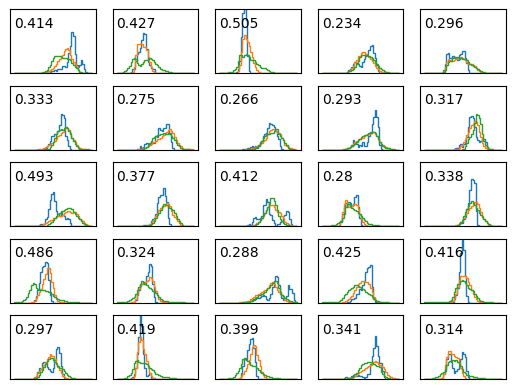

In [64]:
bin_edges = np.load(BIN_EDGES_PATH)/np.log(10)

rows = 5
cols = 5

fig, axs = plt.subplots(rows, cols)

for row in range(rows):
    for col in range(cols):
        ax = axs[row][col]
        ax.set_ylim(0,0.25)
        ax.set_xticks([])
        ax.set_yticks([])
        i = row*cols + col
        ax.stairs(eval_result_bilstm['targets'][i,:], bin_edges)
        ax.stairs(eval_result_bilstm['preds'][i,:], bin_edges)
        ax.stairs(eval_result_glm_baseline['preds'][i,:], bin_edges)
        ax.text(-3, 0.18, f'{eval_result['js_scores'][i]:.3g}', fontsize=10)


# Direct output similarity

In [287]:
eval_results.keys()

dict_keys(['naive_baseline', 'length_baseline', 'glm_baseline', 'mean_pool_mlp', 'all_local_mlp', 'bilstm', 'lstm_rna_fm', 'struct_lstm_rna_fm', 'transformer_rna_fm', 'loc_rna_fm'])

In [288]:
eval_results['naive_baseline'].keys()

dict_keys(['preds', 'targets', 'js_scores', 'js_mean', 'js_median', 'num_params', 'wasserstein_scores', 'wasserstein_mean', 'wasserstein_median'])

In [126]:
arr_mean_js = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # mean js between different model outputs
arr_median_js = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # median js between different model outputs

for i in range(len(MODEL_ORDER)):
    name_i = MODEL_ORDER[i]
    #for j in range(i+1,len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        name_j = MODEL_ORDER[j]
        arr_js_ij = js_dist(eval_results[name_i]['preds'], eval_results[name_j]['preds'])
        arr_mean_js[i,j] = np.mean(arr_js_ij)
        arr_median_js[i,j] = np.median(arr_js_ij)

In [127]:
arr_mean_js

array([[0.        , 0.31953862, 0.31279045, 0.37190595, 0.38375932,
        0.39854646, 0.37814739, 0.39441556, 0.36944541, 0.35715559],
       [0.31953862, 0.        , 0.16789518, 0.22138558, 0.22138774,
        0.23773427, 0.20458953, 0.24149872, 0.17351751, 0.16886544],
       [0.31279045, 0.16789518, 0.        , 0.19623365, 0.20636916,
        0.22016743, 0.19803898, 0.23145102, 0.16911419, 0.17736718],
       [0.37190595, 0.22138558, 0.19623365, 0.        , 0.12912337,
        0.12052009, 0.16202584, 0.15258375, 0.18611057, 0.17906407],
       [0.38375932, 0.22138774, 0.20636916, 0.12912337, 0.        ,
        0.15805873, 0.16758607, 0.17840503, 0.18982308, 0.18548724],
       [0.39854646, 0.23773427, 0.22016743, 0.12052009, 0.15805873,
        0.        , 0.16395253, 0.13450299, 0.18562149, 0.18311311],
       [0.37814739, 0.20458953, 0.19803898, 0.16202584, 0.16758607,
        0.16395253, 0.        , 0.15793763, 0.14332348, 0.13940147],
       [0.39441556, 0.24149872, 0.2314510

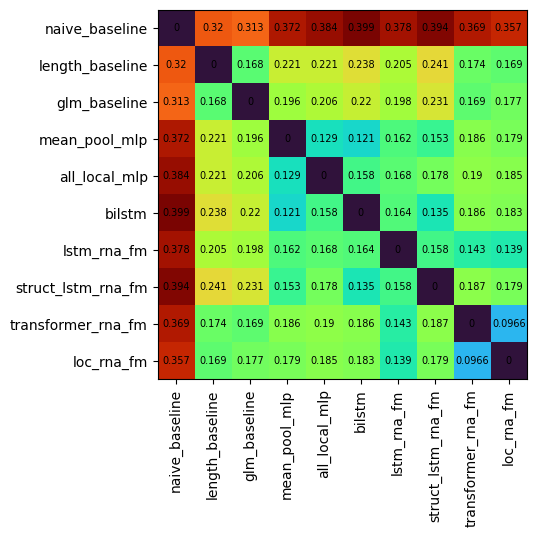

In [128]:
fig, ax = plt.subplots()

data = arr_mean_js

ax.imshow(data, cmap='turbo')

for y in range(data.shape[0]):
    for x in range(data.shape[1]):
        plt.text(x, y, '%.3g' % data[y, x],
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=7
                 )

ax.set_xticks(np.arange(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER)
ax.set_yticks(np.arange(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER)
ax.tick_params(axis='x', labelrotation=90)

In [290]:
arr_mean_w = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # mean js between different model outputs
arr_median_w = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # median js between different model outputs

for i in range(len(MODEL_ORDER)):
    name_i = MODEL_ORDER[i]
    #for j in range(i+1,len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        name_j = MODEL_ORDER[j]
        arr_w_ij = wasserstein_dist(BIN_CENTERS, eval_results[name_i]['preds'], eval_results[name_j]['preds'])
        arr_mean_w[i,j] = np.mean(arr_w_ij)
        arr_median_w[i,j] = np.median(arr_w_ij)

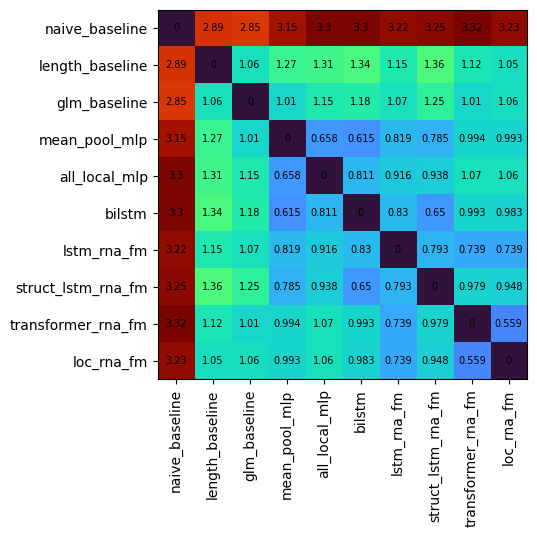

In [292]:
fig, ax = plt.subplots()

data = arr_mean_w

ax.imshow(data, cmap='turbo')

for y in range(data.shape[0]):
    for x in range(data.shape[1]):
        plt.text(x, y, '%.3g' % data[y, x],
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=7
                 )

ax.set_xticks(np.arange(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER)
ax.set_yticks(np.arange(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER)
ax.tick_params(axis='x', labelrotation=90)

# Error correlations, old model order (the one we will keep)

In [334]:
arr_corr_kl = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # correlation between js scores

for i in range(len(MODEL_ORDER)):
    name_i = MODEL_ORDER[i]
    #for j in range(i+1,len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        name_j = MODEL_ORDER[j]
        kl_i = eval_results[name_i]['kl_scores']
        kl_j = eval_results[name_j]['kl_scores']
        result = pearsonr(kl_i, kl_j)
        arr_corr_kl[i,j] = result.statistic

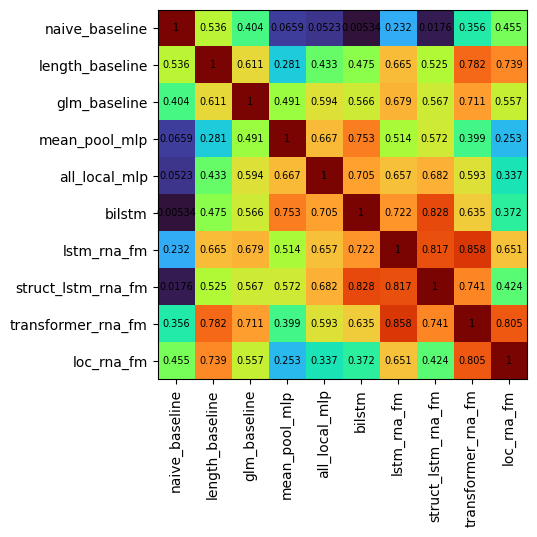

In [336]:
fig, ax = plt.subplots()

data = np.abs(arr_corr_kl)

ax.imshow(data, cmap='turbo')
#ax.imshow(data, cmap='jet')
#ax.imshow(data, cmap='gnuplot2')

for y in range(data.shape[0]):
    for x in range(data.shape[1]):
        plt.text(x, y, '%.3g' % data[y, x],
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=7
                 )

ax.set_xticks(np.arange(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER)
ax.set_yticks(np.arange(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER)
ax.tick_params(axis='x', labelrotation=90)

In [293]:
arr_corr_js = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # correlation between js scores

for i in range(len(MODEL_ORDER)):
    name_i = MODEL_ORDER[i]
    #for j in range(i+1,len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        name_j = MODEL_ORDER[j]
        js_i = eval_results[name_i]['js_scores']
        js_j = eval_results[name_j]['js_scores']
        result = pearsonr(js_i, js_j)
        arr_corr_js[i,j] = result.statistic

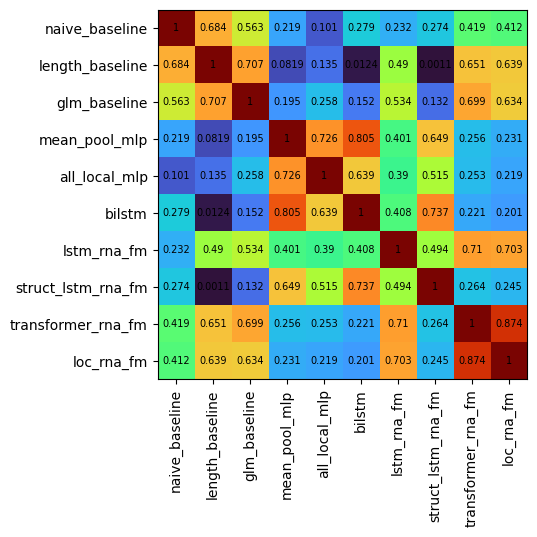

In [ ]:
fig, ax = plt.subplots()

#data = new_arr_corr**2
data = np.abs(arr_corr_js)

ax.imshow(data, cmap='turbo')
#ax.imshow(data, cmap='jet')
#ax.imshow(data, cmap='gnuplot2')

for y in range(data.shape[0]):
    for x in range(data.shape[1]):
        plt.text(x, y, '%.3g' % data[y, x],
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=7
                 )

ax.set_xticks(np.arange(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER)
ax.set_yticks(np.arange(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER)
ax.tick_params(axis='x', labelrotation=90)

# plt.savefig('error_correlations_js.png', bbox_inches='tight')
# plt.savefig('error_correlations_js.pdf', bbox_inches='tight')

In [297]:
arr_corr_w = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # correlation between wasserstein scores

for i in range(len(MODEL_ORDER)):
    name_i = MODEL_ORDER[i]
    #for j in range(i+1,len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        name_j = MODEL_ORDER[j]
        w_i = eval_results[name_i]['wasserstein_scores']
        w_j = eval_results[name_j]['wasserstein_scores']
        result = pearsonr(w_i, w_j)
        arr_corr_w[i,j] = result.statistic

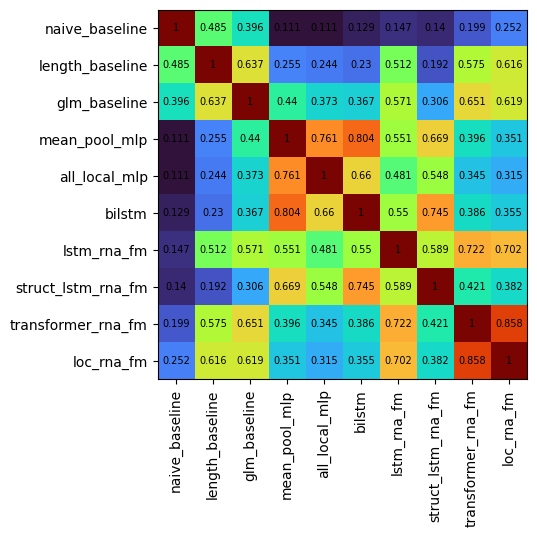

In [299]:
fig, ax = plt.subplots()

#data = new_arr_corr**2
data = np.abs(arr_corr_w)

ax.imshow(data, cmap='turbo')
#ax.imshow(data, cmap='jet')
#ax.imshow(data, cmap='gnuplot2')

for y in range(data.shape[0]):
    for x in range(data.shape[1]):
        plt.text(x, y, '%.3g' % data[y, x],
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=7
                 )

ax.set_xticks(np.arange(len(MODEL_ORDER)))
ax.set_xticklabels(MODEL_ORDER)
ax.set_yticks(np.arange(len(MODEL_ORDER)))
ax.set_yticklabels(MODEL_ORDER)
ax.tick_params(axis='x', labelrotation=90)

# plt.savefig('error_correlations_js.png', bbox_inches='tight')
# plt.savefig('error_correlations_js.pdf', bbox_inches='tight')

# Error correlations, new model order (swapped lstm_rna_fm and struct_lstm_rna_fm)

In [701]:
arr_corr_js = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # correlation between js scores

for i in range(len(MODEL_ORDER)):
    name_i = MODEL_ORDER[i]
    #for j in range(i+1,len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        name_j = MODEL_ORDER[j]
        js_i = eval_results[name_i]['js_scores']
        js_j = eval_results[name_j]['js_scores']
        result = pearsonr(js_i, js_j)
        arr_corr_js[i,j] = result.statistic

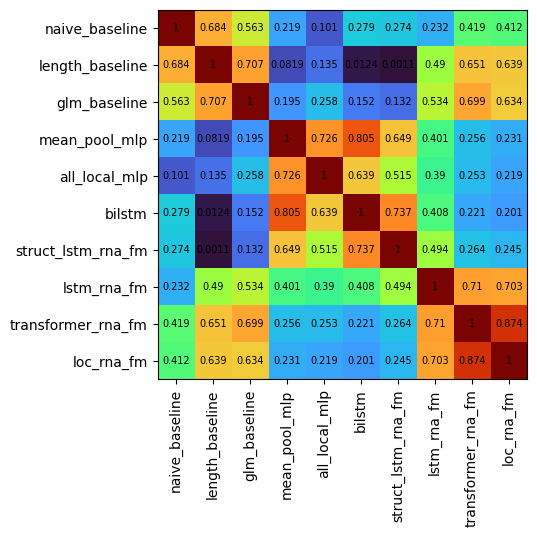

In [702]:
NEW_MODEL_ORDER = MODEL_ORDER.copy()
temp = NEW_MODEL_ORDER[-4]
NEW_MODEL_ORDER[-4] = NEW_MODEL_ORDER[-3]
NEW_MODEL_ORDER[-3] = temp

new_arr_corr = arr_corr_js.copy()
temp = new_arr_corr[-4,:].copy()
new_arr_corr[-4,:] = new_arr_corr[-3,:]
new_arr_corr[-3,:] = temp
temp = new_arr_corr[:,-4].copy()
new_arr_corr[:,-4] = new_arr_corr[:,-3]
new_arr_corr[:,-3] = temp

fig, ax = plt.subplots()

#data = new_arr_corr**2
data = np.abs(new_arr_corr)

ax.imshow(data, cmap='turbo')
#ax.imshow(data, cmap='jet')
#ax.imshow(data, cmap='gnuplot2')

for y in range(data.shape[0]):
    for x in range(data.shape[1]):
        plt.text(x, y, '%.3g' % data[y, x],
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=7
                 )

ax.set_xticks(np.arange(len(NEW_MODEL_ORDER)))
ax.set_xticklabels(NEW_MODEL_ORDER)
ax.set_yticks(np.arange(len(NEW_MODEL_ORDER)))
ax.set_yticklabels(NEW_MODEL_ORDER)
ax.tick_params(axis='x', labelrotation=90)

plt.savefig('error_correlations_js.png', bbox_inches='tight')
plt.savefig('error_correlations_js.pdf', bbox_inches='tight')

In [156]:
arr_corr_w = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # correlation between wasserstein scores

for i in range(len(MODEL_ORDER)):
    name_i = MODEL_ORDER[i]
    #for j in range(i+1,len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        name_j = MODEL_ORDER[j]
        w_i = eval_results[name_i]['wasserstein_scores']
        w_j = eval_results[name_j]['wasserstein_scores']
        result = pearsonr(w_i, w_j)
        arr_corr_w[i,j] = result.statistic

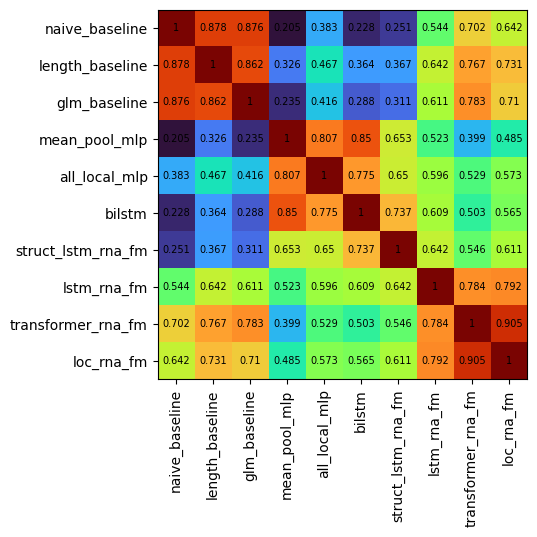

In [201]:
NEW_MODEL_ORDER = MODEL_ORDER.copy()
temp = NEW_MODEL_ORDER[-4]
NEW_MODEL_ORDER[-4] = NEW_MODEL_ORDER[-3]
NEW_MODEL_ORDER[-3] = temp

new_arr_corr = arr_corr_w.copy()
temp = new_arr_corr[-4,:].copy()
new_arr_corr[-4,:] = new_arr_corr[-3,:]
new_arr_corr[-3,:] = temp
temp = new_arr_corr[:,-4].copy()
new_arr_corr[:,-4] = new_arr_corr[:,-3]
new_arr_corr[:,-3] = temp


fig, ax = plt.subplots()

data = np.abs(new_arr_corr)

ax.imshow(data, cmap='turbo')

for y in range(data.shape[0]):
    for x in range(data.shape[1]):
        plt.text(x, y, '%.3g' % data[y, x],
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=7
                 )

ax.set_xticks(np.arange(len(NEW_MODEL_ORDER)))
ax.set_xticklabels(NEW_MODEL_ORDER)
ax.set_yticks(np.arange(len(NEW_MODEL_ORDER)))
ax.set_yticklabels(NEW_MODEL_ORDER)
ax.tick_params(axis='x', labelrotation=90)

plt.savefig('error_correlations_wasserstein.png', bbox_inches='tight')
plt.savefig('error_correlations_wasserstein.pdf', bbox_inches='tight')

# Evaluation metrics vs parameter count

In [169]:
list_paramcount = []
list_jsmean = []
list_wmean = []

for i in range(len(MODEL_ORDER)):
    list_paramcount.append(eval_results[MODEL_ORDER[i]]['num_params'])
    list_jsmean.append(eval_results[MODEL_ORDER[i]]['js_mean'])
    list_wmean.append(eval_results[MODEL_ORDER[i]]['wasserstein_mean'])

arr_paramcount = np.array(list_paramcount)
arr_jsmean = np.array(list_jsmean)
arr_wmean = np.array(list_wmean)

Text(0, 0.5, 'test set js')

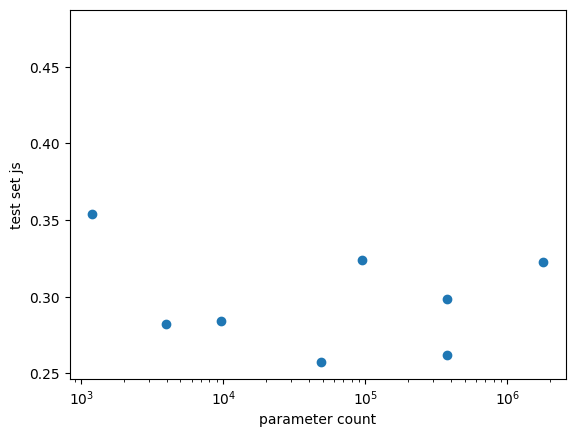

In [209]:
plt.xscale('log')
plt.scatter(arr_paramcount, arr_jsmean)
#plt.scatter(arr_paramcount, arr_jsmean/np.mean(arr_jsmean))
#plt.scatter(arr_paramcount, arr_wmean/np.mean(arr_wmean))
#plt.ylim(0.6,1.2)
plt.xlabel('parameter count')
plt.ylabel('test set js')

Text(0, 0.5, 'test set js error')

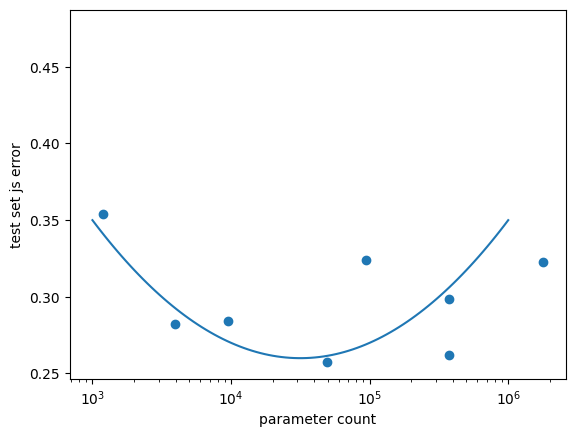

In [219]:
plt.xscale('log')
plt.scatter(arr_paramcount, arr_jsmean)
#plt.scatter(arr_paramcount, arr_jsmean/np.mean(arr_jsmean))
#plt.scatter(arr_paramcount, arr_wmean/np.mean(arr_wmean))
#plt.ylim(0.6,1.2)
arr_x = np.logspace(3,6,100)
plt.plot(arr_x, 0.04*(np.log10(arr_x)-4.5)**2 + 0.26)
plt.xlabel('parameter count')
plt.ylabel('test set js error')

# 2026-08-28: Figure with everything

In [703]:
arr_corr_kl = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # correlation between js scores

for i in range(len(MODEL_ORDER)):
    name_i = MODEL_ORDER[i]
    #for j in range(i+1,len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        name_j = MODEL_ORDER[j]
        kl_i = eval_results[name_i]['kl_scores']
        kl_j = eval_results[name_j]['kl_scores']
        result = pearsonr(kl_i, kl_j)
        arr_corr_kl[i,j] = result.statistic

arr_corr_js = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # correlation between js scores
for i in range(len(MODEL_ORDER)):
    name_i = MODEL_ORDER[i]
    #for j in range(i+1,len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        name_j = MODEL_ORDER[j]
        js_i = eval_results[name_i]['js_scores']
        js_j = eval_results[name_j]['js_scores']
        result = pearsonr(js_i, js_j)
        arr_corr_js[i,j] = result.statistic

arr_corr_w = np.zeros((len(MODEL_ORDER),len(MODEL_ORDER))) # correlation between wasserstein scores
for i in range(len(MODEL_ORDER)):
    name_i = MODEL_ORDER[i]
    #for j in range(i+1,len(MODEL_ORDER)):
    for j in range(len(MODEL_ORDER)):
        name_j = MODEL_ORDER[j]
        w_i = eval_results[name_i]['wasserstein_scores']
        w_j = eval_results[name_j]['wasserstein_scores']
        result = pearsonr(w_i, w_j)
        arr_corr_w[i,j] = result.statistic

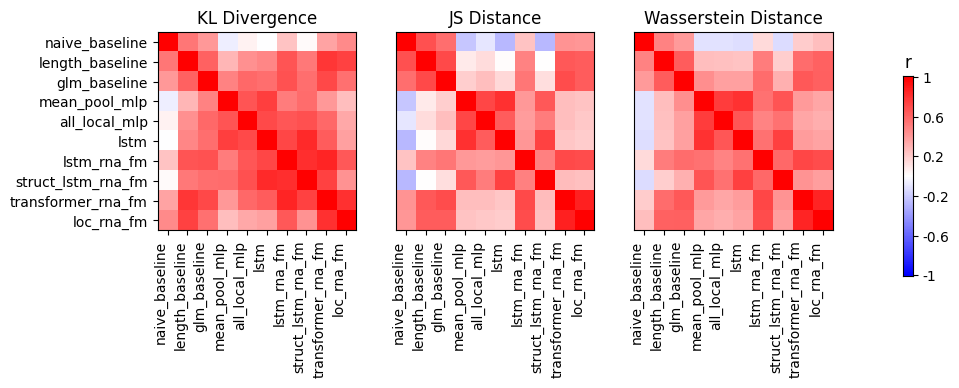

In [ ]:
MODEL_ORDER_PLOT = MODEL_ORDER.copy()
MODEL_ORDER_PLOT[5] = 'lstm'

num_axs = 3
fig, axs = plt.subplots(1,num_axs,figsize=(10,10))

for i in range(num_axs):
    ax = axs[i]
    if i==0:
        data = arr_corr_kl
        ax.set_title('KL Divergence')
    if i==1:
        data = arr_corr_js
        ax.set_title('JS Distance')
    elif i==2:
        data = arr_corr_w
        ax.set_title('Wasserstein Distance')
    
    #data = np.abs(data)

    #ax.imshow(data, cmap='turbo')
    #ax.imshow(data, cmap='jet')
    #ax.imshow(data, cmap='gnuplot2')
    #ax.imshow(data, cmap='Greys')
    ax.imshow(data, cmap='bwr', vmin=-1, vmax=1)

    # for y in range(data.shape[0]):
    #     for x in range(data.shape[1]):
    #         ax.text(x, y, f'{data[y,x]:.2f}'.replace('0.','.'),
    #                 horizontalalignment='center',
    #                 verticalalignment='center',
    #                 fontsize=7
    #                 )

    ax.set_xticks(np.arange(len(MODEL_ORDER_PLOT)))
    ax.set_xticklabels(MODEL_ORDER_PLOT)
    ax.tick_params(axis='x', labelrotation=90)
    plt.setp(ax.get_xticklabels(), ha='right')
    if i==0:
        ax.set_yticks(np.arange(len(MODEL_ORDER_PLOT)))
        ax.set_yticklabels(MODEL_ORDER_PLOT)
    else:
        ax.set_yticks([])

plt.subplots_adjust(right=0.8)
ax = fig.add_axes([0.85,0.35,0.05,0.2])
ax.imshow(np.outer(np.ones(5),np.linspace(1,-1,101)).T, cmap='bwr', vmin=-1, vmax=1)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_yticks([0,20,40,60,80,100])
ax.set_yticklabels([1,0.6,0.2,-0.2,-0.6,-1])
ax.set_xticks([])
ax.set_title('r')

plt.savefig('error_corr_bwr_2.png', bbox_inches='tight')
plt.savefig('error_corr_bwr_2.pdf', bbox_inches='tight')

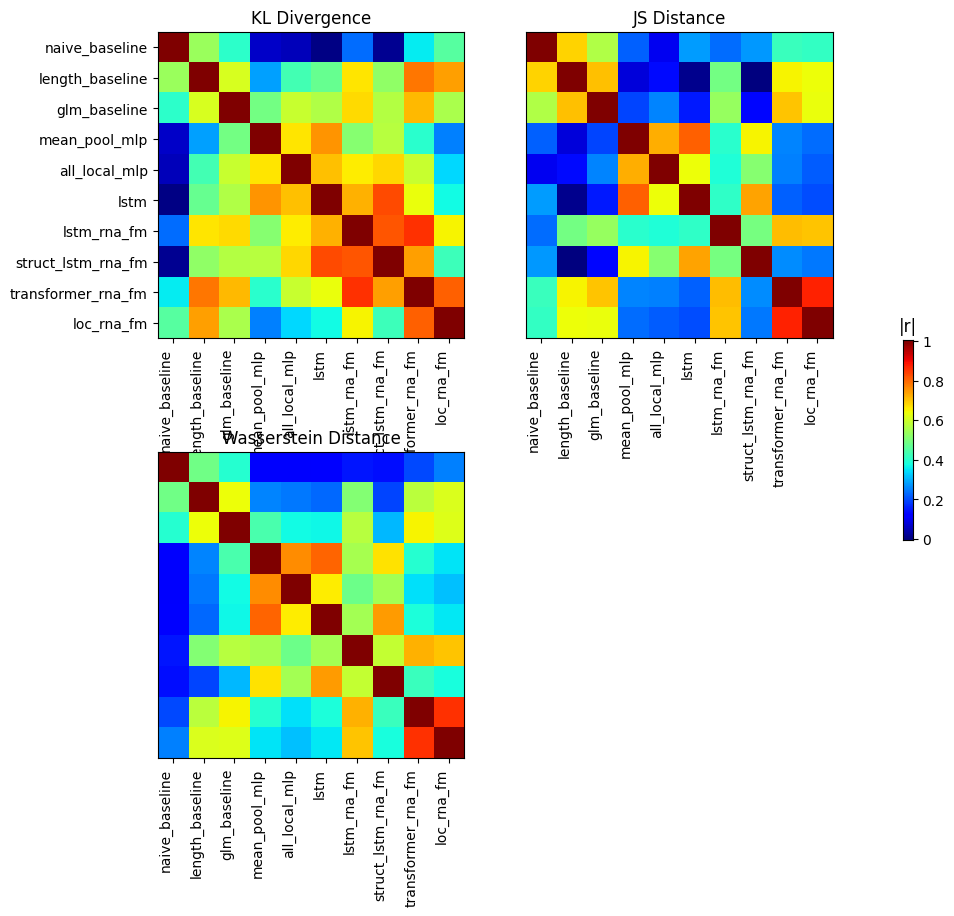

In [ ]:
MODEL_ORDER_PLOT = MODEL_ORDER.copy()
MODEL_ORDER_PLOT[5] = 'lstm'

num_axs = 3
fig, axs = plt.subplots(1,num_axs,figsize=(10,10))

for i in range(num_axs):
    ax = axs[i]
    if i==0:
        data = arr_corr_kl
        ax.set_title('KL Divergence')
    if i==1:
        data = arr_corr_js
        ax.set_title('JS Distance')
    elif i==2:
        data = arr_corr_w
        ax.set_title('Wasserstein Distance')
    
    data = np.abs(data)

    #ax.imshow(data, cmap='turbo')
    ax.imshow(data, cmap='jet', vmin=0, vmax=1)
    #ax.imshow(data, cmap='gnuplot2')
    #ax.imshow(data, cmap='Greys')
    #ax.imshow(data, cmap='bwr', vmin=-1, vmax=1)

    # for y in range(data.shape[0]):
    #     for x in range(data.shape[1]):
    #         ax.text(x, y, f'{data[y,x]:.2f}'.replace('0.','.'),
    #                 horizontalalignment='center',
    #                 verticalalignment='center',
    #                 fontsize=7
    #                 )

    ax.set_xticks(np.arange(len(MODEL_ORDER_PLOT)))
    ax.set_xticklabels(MODEL_ORDER_PLOT)
    ax.tick_params(axis='x', labelrotation=90)
    plt.setp(ax.get_xticklabels(), ha='right')
    if i==0:
        ax.set_yticks(np.arange(len(MODEL_ORDER_PLOT)))
        ax.set_yticklabels(MODEL_ORDER_PLOT)
    else:
        ax.set_yticks([])

plt.subplots_adjust(right=0.8)
ax = fig.add_axes([0.85,0.35,0.05,0.2])
#ax.imshow(np.outer(np.ones(5),np.linspace(1,-1,101)).T, cmap='bwr', vmin=-1, vmax=1)
ax.imshow(np.outer(np.ones(5),np.linspace(1,0,101)).T, cmap='jet', vmin=0, vmax=1)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_yticks([0,20,40,60,80,100])
ax.set_yticklabels([1,0.8,0.6,0.4,0.2,0])
ax.set_xticks([])
ax.set_title('|r|')

plt.savefig('error_corr_jet.png', bbox_inches='tight')
plt.savefig('error_corr_jet.pdf', bbox_inches='tight')

In [313]:
eigenvalues, eigenvectors = np.linalg.eig(arr_corr_js)

In [314]:
eigenvalues

array([4.5333764 , 2.91354405, 0.74518579, 0.41407343, 0.11816942,
       0.33499664, 0.30372218, 0.16838324, 0.23978685, 0.22876133])

In [324]:
eigenvectors[:,0]

array([0.17083737, 0.31911369, 0.35404053, 0.27664054, 0.26994856,
       0.26018877, 0.3926792 , 0.25595301, 0.39818647, 0.38506438])

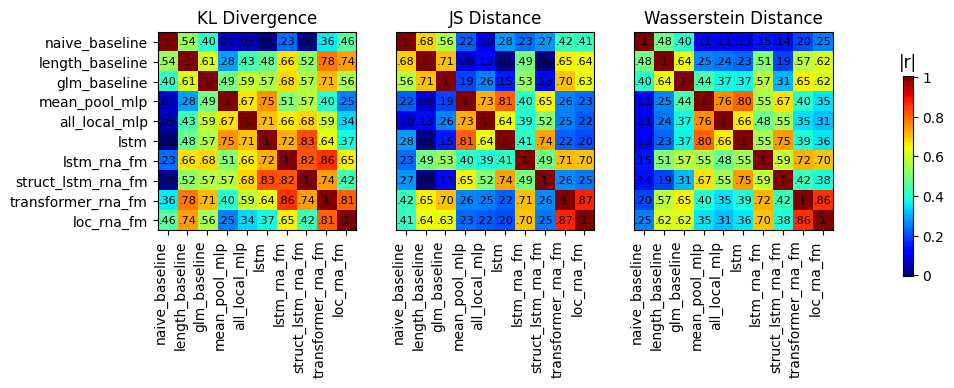

In [391]:
MODEL_ORDER_PLOT = MODEL_ORDER.copy()
MODEL_ORDER_PLOT[5] = 'lstm'

num_axs = 3
fig, axs = plt.subplots(1,num_axs,figsize=(10,10))

for i in range(num_axs):
    ax = axs[i]
    if i==0:
        data = arr_corr_kl
        ax.set_title('KL Divergence')
    if i==1:
        data = arr_corr_js
        ax.set_title('JS Distance')
    elif i==2:
        data = arr_corr_w
        ax.set_title('Wasserstein Distance')
    
    data = np.abs(data)

    #ax.imshow(data, cmap='turbo')
    ax.imshow(data, cmap='jet', vmin=0, vmax=1)
    #ax.imshow(data, cmap='gnuplot2')
    #ax.imshow(data, cmap='Greys')
    #ax.imshow(data, cmap='bwr', vmin=-1, vmax=1)

    for y in range(data.shape[0]):
        for x in range(data.shape[1]):
            ax.text(x, y, f'{data[y,x]:.2f}'.replace('0.','.').replace('1.00','1'),
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=8
                    )

    ax.set_xticks(np.arange(len(MODEL_ORDER_PLOT)))
    ax.set_xticklabels(MODEL_ORDER_PLOT)
    ax.tick_params(axis='x', labelrotation=90)
    plt.setp(ax.get_xticklabels(), ha='right')
    if i==0:
        ax.set_yticks(np.arange(len(MODEL_ORDER_PLOT)))
        ax.set_yticklabels(MODEL_ORDER_PLOT)
    else:
        ax.set_yticks([])

plt.subplots_adjust(right=0.8)
ax = fig.add_axes([0.85,0.35,0.05,0.2])
#ax.imshow(np.outer(np.ones(5),np.linspace(1,-1,101)).T, cmap='bwr', vmin=-1, vmax=1)
ax.imshow(np.outer(np.ones(5),np.linspace(1,0,101)).T, cmap='jet', vmin=0, vmax=1)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_yticks([0,20,40,60,80,100])
ax.set_yticklabels([1,0.8,0.6,0.4,0.2,0])
ax.set_xticks([])
ax.set_title('|r|')

plt.savefig('error_corr_jet_2.png', bbox_inches='tight')
plt.savefig('error_corr_jet_2.pdf', bbox_inches='tight')

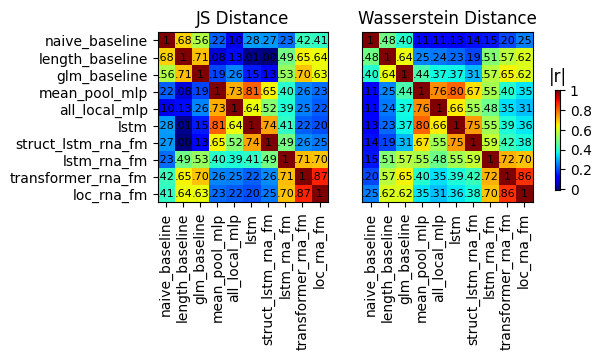

In [724]:
NEW_MODEL_ORDER = MODEL_ORDER.copy()
temp = NEW_MODEL_ORDER[-4]
NEW_MODEL_ORDER[-4] = NEW_MODEL_ORDER[-3]
NEW_MODEL_ORDER[-3] = temp

MODEL_ORDER_PLOT = NEW_MODEL_ORDER.copy()
MODEL_ORDER_PLOT[5] = 'lstm'

num_axs = 2
fig, axs = plt.subplots(1,num_axs,figsize=(5,5))

for i in range(num_axs):
    ax = axs[i]
    if i==0:
        data = arr_corr_js
        ax.set_title('JS Distance')
    elif i==1:
        data = arr_corr_w
        ax.set_title('Wasserstein Distance')
    
    data = np.abs(data)

    new_arr_corr = data.copy()
    temp = new_arr_corr[-4,:].copy()
    new_arr_corr[-4,:] = new_arr_corr[-3,:]
    new_arr_corr[-3,:] = temp
    temp = new_arr_corr[:,-4].copy()
    new_arr_corr[:,-4] = new_arr_corr[:,-3]
    new_arr_corr[:,-3] = temp

    data = new_arr_corr

    #ax.imshow(data, cmap='turbo')
    ax.imshow(data, cmap='jet', vmin=0, vmax=1)
    #ax.imshow(data, cmap='gnuplot2')
    #ax.imshow(data, cmap='Greys')
    #ax.imshow(data, cmap='bwr', vmin=-1, vmax=1)

    for y in range(data.shape[0]):
        for x in range(data.shape[1]):
            ax.text(x, y, f'{data[y,x]:.2f}'.replace('0.','.').replace('1.00','1'),
                    horizontalalignment='center',
                    verticalalignment='center',
                    fontsize=8
                    )

    ax.tick_params(axis='x', labelrotation=90)
    ax.set_xticks(np.arange(len(MODEL_ORDER_PLOT)))
    ax.set_xticklabels(MODEL_ORDER_PLOT, ha='center', va='top')
    #plt.setp(ax.get_xticklabels(), ha='right', va='center')
    if i==0:
        ax.set_yticks(np.arange(len(MODEL_ORDER_PLOT)))
        ax.set_yticklabels(MODEL_ORDER_PLOT)
    else:
        ax.set_yticks([])

plt.subplots_adjust(right=0.875)
ax = fig.add_axes([0.9,0.35,0.05,0.2])
#ax.imshow(np.outer(np.ones(5),np.linspace(1,-1,101)).T, cmap='bwr', vmin=-1, vmax=1)
ax.imshow(np.outer(np.ones(5),np.linspace(1,0,101)).T, cmap='jet', vmin=0, vmax=1)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_yticks([0,20,40,60,80,100])
ax.set_yticklabels([1,0.8,0.6,0.4,0.2,0])
ax.set_xticks([])
ax.set_title('|r|')

plt.savefig('error_corr_jet_3.png', bbox_inches='tight')
plt.savefig('error_corr_jet_3.pdf', bbox_inches='tight')

# 2026-08-30: Correlation of distribution centers

In [733]:
eval_results.keys()

dict_keys(['naive_baseline', 'length_baseline', 'glm_baseline', 'mean_pool_mlp', 'all_local_mlp', 'bilstm', 'lstm_rna_fm', 'struct_lstm_rna_fm', 'transformer_rna_fm', 'loc_rna_fm'])

In [734]:
eval_results['naive_baseline']['preds'].shape

(1549, 50)

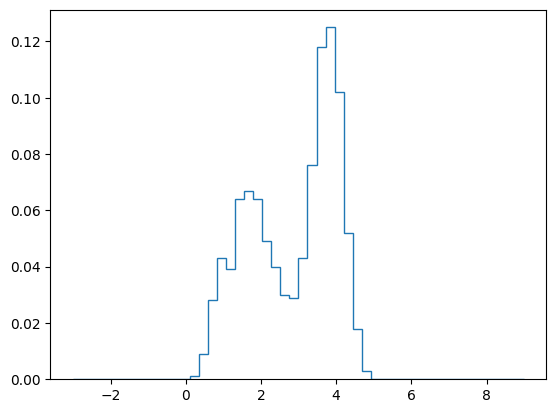

In [741]:
i = 20

plt.stairs(eval_results['naive_baseline']['targets'][i], BIN_EDGES)

In [ ]:
hist = eval_results['naive_baseline']['targets'][i]
low = np.average(BIN_EDGES[:-1], weights=hist)
high = np.average(BIN_EDGES[1:], weights=hist)
mid = np.average(BIN_CENTERS, weights=hist)
print(f'The average is approx. {mid}, in the {low}-{high} range.')

cumsum = np.cumsum(hist)
idx = np.searchsorted(cumsum, 0.5)
low = BIN_EDGES[idx-1]
high = BIN_EDGES[idx]
mid = low + (0.5 - cumsum[idx-1])/(cumsum[idx]-cumsum[idx-1])*(high-low)
print(f'The median is approx. {mid}, in the {low}-{high} range.')

The average is approx. 3.3954809560042802, in the 3.2755357019475113-3.5154262100610487 range.
The median is approx. 2.9575815602450746, in the 2.757372194724921-2.9972627028384595 range.


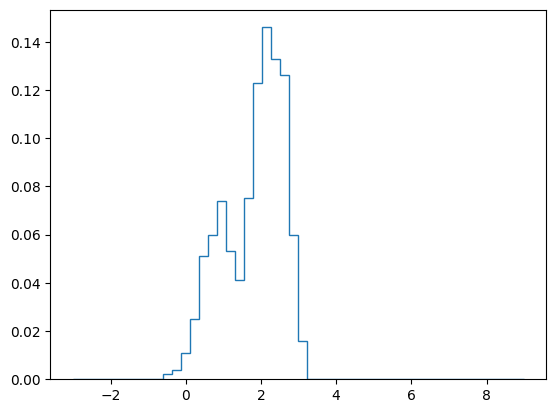

In [740]:
plt.stairs(eval_results['naive_baseline']['targets'][i], BIN_EDGES)

In [737]:
for model in MODEL_ORDER:
    preds = eval_results[model]['preds']
    targets = eval_results[model]['targets']
    eval_results[model]['pred_medians'] = []
    eval_results[model]['target_medians'] = []
    for i in range(preds.shape[0]):
        hist = preds[i,:]
        cumsum = np.cumsum(hist)
        idx = np.searchsorted(cumsum, 0.5)
        low = BIN_EDGES[idx-1]
        high = BIN_EDGES[idx]
        median = low + (0.5 - cumsum[idx-1])/(cumsum[idx]-cumsum[idx-1])*(high-low)
        eval_results[model]['pred_medians'].append(median)

        hist = targets[i,:]
        cumsum = np.cumsum(hist)
        idx = np.searchsorted(cumsum, 0.5)
        low = BIN_EDGES[idx-1]
        high = BIN_EDGES[idx]
        median = low + (0.5 - cumsum[idx-1])/(cumsum[idx]-cumsum[idx-1])*(high-low)
        eval_results[model]['target_medians'].append(median)

    eval_results[model]['pred_medians'] = np.array(eval_results[model]['pred_medians'])
    eval_results[model]['target_medians'] = np.array(eval_results[model]['target_medians'])
    
    result = pearsonr(eval_results[model]['pred_medians'], eval_results[model]['target_medians'])
    eval_results[model]['median_corr'] = result.statistic

    print(model, eval_results[model]['median_corr'])

C:\Users\Julius\AppData\Local\Temp\ipykernel_1680\449741209.py:26: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  result = pearsonr(eval_results[model]['pred_medians'], eval_results[model]['target_medians'])


naive_baseline nan
length_baseline 0.824480771794619
glm_baseline 0.8647856784852562
mean_pool_mlp 0.9032917669400977
all_local_mlp 0.9062769746004755
bilstm 0.925969693133723
lstm_rna_fm 0.8929461162844503
struct_lstm_rna_fm 0.9218510793494821
transformer_rna_fm 0.8843155874822857
loc_rna_fm 0.878099375661829


In [749]:
all_local_data = (name == "all_local_mlp")
handpicked_cols = ["gc_content", "mfe", "n_local_minima"]
set_seed(SEED)
data = prepare_data(
    DATA_PATH, n_bins=N_BINS, random_state=SEED, handpicked_cols=handpicked_cols,
    bin_edges_path=BIN_EDGES_PATH, data_mask=None,
    local_minima_k=10 if all_local_data else None,
)

In [760]:
test_seq_lengths = []

for i in range(len(data.test.sequences)):
    test_seq_lengths.append(data.test.sequences[i].shape[0])

test_seq_lengths = np.array(test_seq_lengths)

In [781]:
np.linspace(151,15,151-15+1)

array([151., 150., 149., 148., 147., 146., 145., 144., 143., 142., 141.,
       140., 139., 138., 137., 136., 135., 134., 133., 132., 131., 130.,
       129., 128., 127., 126., 125., 124., 123., 122., 121., 120., 119.,
       118., 117., 116., 115., 114., 113., 112., 111., 110., 109., 108.,
       107., 106., 105., 104., 103., 102., 101., 100.,  99.,  98.,  97.,
        96.,  95.,  94.,  93.,  92.,  91.,  90.,  89.,  88.,  87.,  86.,
        85.,  84.,  83.,  82.,  81.,  80.,  79.,  78.,  77.,  76.,  75.,
        74.,  73.,  72.,  71.,  70.,  69.,  68.,  67.,  66.,  65.,  64.,
        63.,  62.,  61.,  60.,  59.,  58.,  57.,  56.,  55.,  54.,  53.,
        52.,  51.,  50.,  49.,  48.,  47.,  46.,  45.,  44.,  43.,  42.,
        41.,  40.,  39.,  38.,  37.,  36.,  35.,  34.,  33.,  32.,  31.,
        30.,  29.,  28.,  27.,  26.,  25.,  24.,  23.,  22.,  21.,  20.,
        19.,  18.,  17.,  16.,  15.])

In [ ]:
(151-15+1)/

137

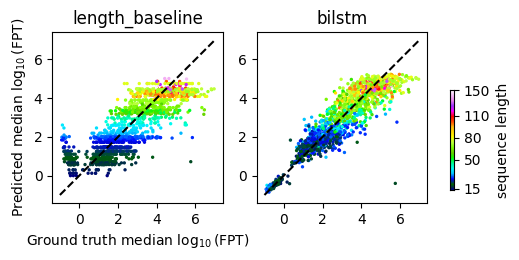

In [794]:
fig, axs = plt.subplots(1,2, figsize=(5,5))

for i in range(2):
    if i==0:
        model = 'length_baseline'
    elif i==1:
        model = 'bilstm'
    ax = axs[i]
    ax.set_aspect('equal')
    ax.scatter(eval_results[model]['target_medians'],
            eval_results[model]['pred_medians'],
            s=2,
            c=test_seq_lengths,cmap='gist_ncar')

    ax.plot([-1,7],[-1,7],linestyle='--',color='black')
    if i==0:
        ax.set_ylabel(r'Predicted median $\log_{10}(\text{FPT})$')
        ax.set_xlabel(r'Ground truth median $\log_{10}(\text{FPT})$')
    ax.set_xticks([0,2,4,6])
    ax.set_yticks([0,2,4,6])
    ax.set_title(model)

plt.subplots_adjust(right=0.875)
ax = fig.add_axes([0.9,0.35,0.05,0.2])
#ax.imshow(np.outer(np.ones(5),np.linspace(1,-1,101)).T, cmap='bwr', vmin=-1, vmax=1)
ax.imshow(np.outer(np.ones(5),np.linspace(151,15,151-15+1)).T,
          cmap='gist_ncar', vmin=15, vmax=151)
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ytick_seqlengths = np.array([15,50,80,110,150])
ax.set_yticks(ytick_seqlengths-15)
ax.set_yticklabels(np.flip(ytick_seqlengths))
ax.set_xticks([])
ax.set_ylabel('sequence length')

plt.savefig('median_corr.png', bbox_inches='tight')
plt.savefig('median_corr.pdf', bbox_inches='tight')

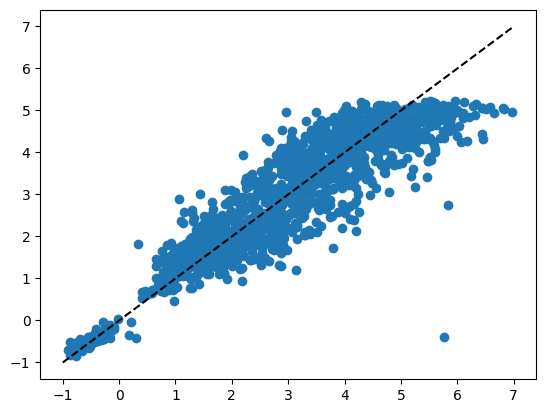

In [739]:
plt.scatter(eval_results['bilstm']['target_medians'],
            eval_results['bilstm']['pred_medians'])

plt.plot([-1,7],[-1,7],linestyle='--',color='black')

In [482]:
for model in MODEL_ORDER:
    preds = eval_results[model]['preds']
    targets = eval_results[model]['targets']
    eval_results[model]['pred_means'] = []
    eval_results[model]['target_means'] = []
    for i in range(preds.shape[0]):
        hist = preds[i,:]
        mean = np.average(BIN_CENTERS, weights=hist)
        eval_results[model]['pred_means'].append(mean)

        hist = targets[i,:]
        mean = np.average(BIN_CENTERS, weights=hist)
        eval_results[model]['target_means'].append(mean)

    eval_results[model]['pred_means'] = np.array(eval_results[model]['pred_means'])
    eval_results[model]['target_means'] = np.array(eval_results[model]['target_means'])
    
    result = pearsonr(eval_results[model]['pred_means'], eval_results[model]['target_means'])
    eval_results[model]['mean_corr'] = result.statistic

    print(model, eval_results[model]['mean_corr'])

C:\Users\Julius\AppData\Local\Temp\ipykernel_1680\2304480290.py:18: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  result = pearsonr(eval_results[model]['pred_means'], eval_results[model]['target_means'])


naive_baseline nan
length_baseline 0.8478324476188159
glm_baseline 0.8911859488116258
mean_pool_mlp 0.9303736664759101
all_local_mlp 0.9325289405010688
bilstm 0.9469077813003772
lstm_rna_fm 0.9180004848900969
struct_lstm_rna_fm 0.9447603816192116
transformer_rna_fm 0.9028884174221183
loc_rna_fm 0.8974186783279414


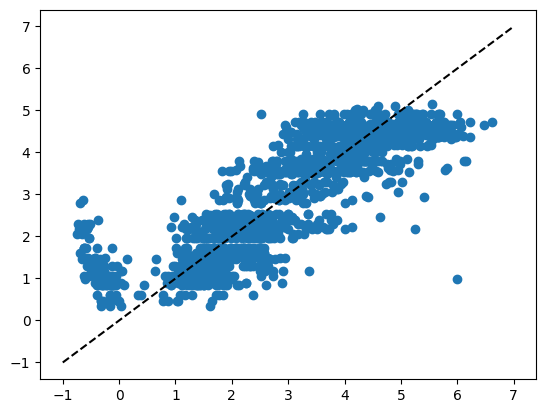

In [454]:
plt.scatter(eval_results['length_baseline']['target_means'],
            eval_results['length_baseline']['pred_means'])

plt.plot([-1,7],[-1,7],linestyle='--',color='black')

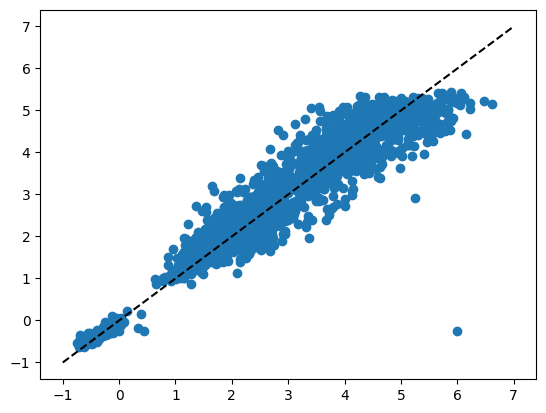

In [452]:
plt.scatter(eval_results['bilstm']['target_means'],
            eval_results['bilstm']['pred_means'])

plt.plot([-1,7],[-1,7],linestyle='--',color='black')

# num peaks

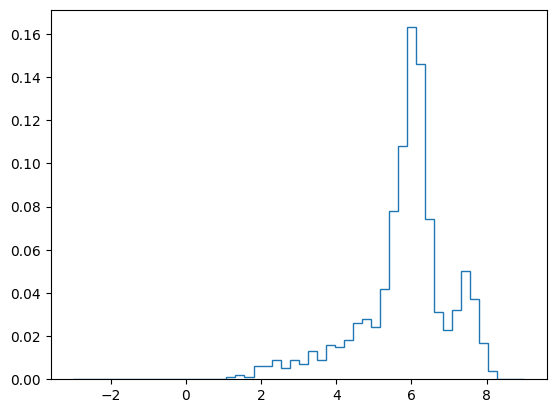

In [667]:
i = 0

hist = eval_results['naive_baseline']['targets'][i]
plt.stairs(hist, bin_edges)

In [668]:
np.sqrt(1000)/1000

np.float64(0.03162277660168379)

In [669]:
find_peaks(hist, prominence=0.005, distance=3, width=1)

(array([37, 43]),
 {'prominences': array([0.163, 0.027]),
  'left_bases': array([16, 41]),
  'right_bases': array([47, 47]),
  'widths': array([3.77916667, 1.77500006]),
  'width_heights': array([0.0815, 0.0365]),
  'left_ips': array([35.11666665, 42.24999995]),
  'right_ips': array([38.89583332, 44.025     ])})

In [670]:
for model in MODEL_ORDER:
    preds = eval_results[model]['preds']
    targets = eval_results[model]['targets']
    eval_results[model]['pred_numpeaks'] = []
    eval_results[model]['target_numpeaks'] = []
    for i in range(preds.shape[0]):
        hist = preds[i,:]
        numpeaks = find_peaks(hist, distance=3, prominence=0.005, width=1)[0].size
        eval_results[model]['pred_numpeaks'].append(numpeaks)

        hist = targets[i,:]
        numpeaks = find_peaks(hist, distance=3, prominence=0.005, width=1)[0].size
        eval_results[model]['target_numpeaks'].append(numpeaks)

    eval_results[model]['pred_numpeaks'] = np.array(eval_results[model]['pred_numpeaks'])
    eval_results[model]['target_numpeaks'] = np.array(eval_results[model]['target_numpeaks'])

In [671]:
eval_results['naive_baseline']['pred_numpeaks']

array([1, 1, 1, ..., 1, 1, 1])

In [672]:
eval_results['naive_baseline']['target_numpeaks'][:100]

array([2, 1, 1, 2, 3, 1, 3, 2, 3, 3, 2, 1, 3, 2, 1, 1, 1, 3, 1, 1, 2, 1,
       1, 2, 2, 1, 1, 2, 3, 1, 1, 2, 2, 1, 2, 1, 1, 3, 1, 2, 1, 1, 2, 2,
       2, 1, 1, 1, 3, 2, 1, 2, 1, 2, 1, 1, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2,
       1, 1, 1, 2, 1, 1, 3, 2, 1, 1, 2, 1, 2, 2, 1, 1, 2, 1, 2, 3, 2, 1,
       2, 1, 1, 3, 1, 2, 1, 4, 2, 2, 3, 1])

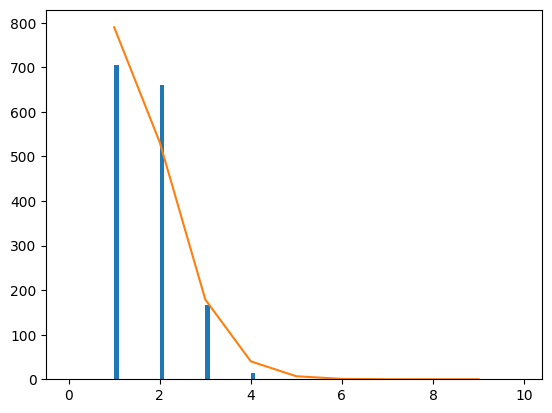

In [673]:
# Interesting: (num_peaks - 1) follows a Poisson distribution

plt.hist(eval_results['naive_baseline']['target_numpeaks'], np.arange(0,10,0.1))
mean_numpeaks = np.mean(eval_results['naive_baseline']['target_numpeaks'])
plt.plot(np.arange(1,10),
         (eval_results['naive_baseline']['target_numpeaks'].shape[0]
          *np.exp(-(mean_numpeaks-1)) * (mean_numpeaks-1)**(np.arange(0,9)) / factorial(np.arange(0,9))) )

10


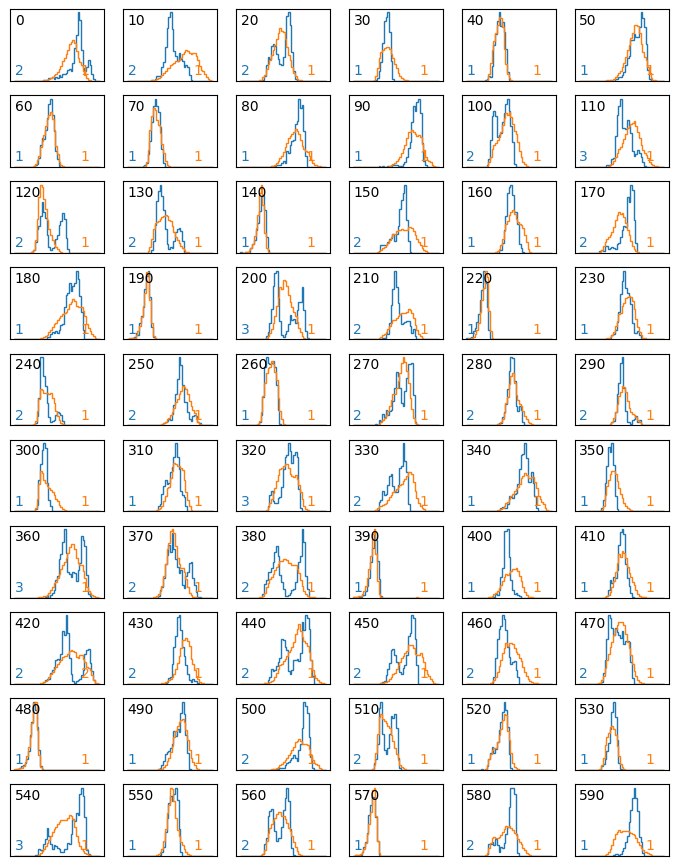

In [674]:
width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

#row_stride = int(eval_results['naive_baseline']['target_numpeaks'].shape[0]/(n_x*n_y))
row_stride = 10
print(row_stride)
counter = 0
for i in range(eval_results['naive_baseline']['target_numpeaks'].shape[0]):
    if i % row_stride == 0:
        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]

        hist = eval_results['naive_baseline']['targets'][i]
        ax.stairs(hist, BIN_EDGES, color='C0')

        hist = eval_results['bilstm']['preds'][i]
        ax.stairs(hist, BIN_EDGES, color='C1')

        ax.set_xticks([])
        ax.set_yticks([])

        
        ax.text(0.05, 0.95, str(i), transform=ax.transAxes, verticalalignment='top')

        num_peaks = eval_results['naive_baseline']['target_numpeaks'][i]
        ax.text(0.05, 0.05, str(num_peaks), transform=ax.transAxes, verticalalignment='bottom', color='C0')

        num_peaks = eval_results['bilstm']['pred_numpeaks'][i]
        ax.text(0.75, 0.05, str(num_peaks), transform=ax.transAxes, verticalalignment='bottom', color='C1')

        counter += 1
        if counter == n_x*n_y:
            break


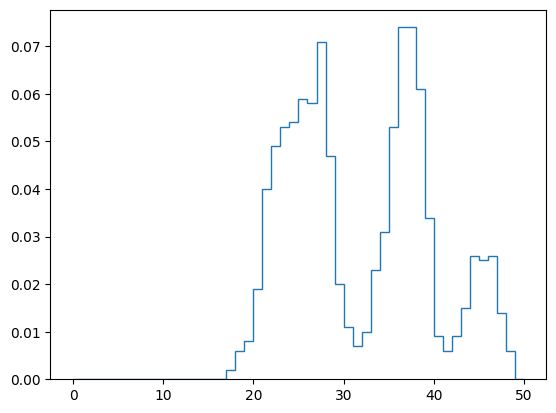

In [675]:
hist = eval_results['naive_baseline']['targets'][28]
#plt.stairs(hist, BIN_EDGES)
plt.stairs(hist)

In [676]:
find_peaks(hist, prominence=0.005, distance=3, width=1)

(array([27, 36, 46]),
 {'prominences': array([0.064, 0.074, 0.02 ]),
  'left_bases': array([16, 16, 41]),
  'right_bases': array([31, 49, 49]),
  'widths': array([7.34391515, 4.61616162, 3.74242421]),
  'width_heights': array([0.039, 0.037, 0.016]),
  'left_ips': array([20.95238105, 34.27272732, 43.09090914]),
  'right_ips': array([28.2962962 , 38.88888893, 46.83333335])})

In [ ]:
model='bilstm'
pred_unimodal = eval_results[model]['pred_numpeaks']==1
target_unimodal = eval_results[model]['target_numpeaks']==1

one_peak_mask = target_unimodal==1
print(np.sum((pred_unimodal == target_unimodal)[one_peak_mask])/np.sum(one_peak_mask))
print(np.sum((pred_unimodal == target_unimodal)[np.logical_not(one_peak_mask)])/np.sum(np.logical_not(one_peak_mask)))

one_peak_mask = pred_unimodal==1
print(np.sum((pred_unimodal == target_unimodal)[one_peak_mask])/np.sum(one_peak_mask))
print(np.sum((pred_unimodal == target_unimodal)[np.logical_not(one_peak_mask)])/np.sum(np.logical_not(one_peak_mask)))

0.9759206798866855
0.08422301304863583
0.47159479808350446
0.8068181818181818


In [700]:
for model in MODEL_ORDER:
    pred_unimodal = eval_results[model]['pred_numpeaks']==1
    target_unimodal = eval_results[model]['target_numpeaks']==1

    one_peak_mask = target_unimodal==1
    recall_1peak = np.sum((pred_unimodal == target_unimodal)[one_peak_mask])/np.sum(one_peak_mask)
    recall_multipeak = np.sum((pred_unimodal == target_unimodal)[np.logical_not(one_peak_mask)])/np.sum(np.logical_not(one_peak_mask))
    eval_results[model]['recall_1peak'] = recall_1peak
    eval_results[model]['recall_multipeak'] = recall_multipeak

    one_peak_mask = pred_unimodal==1
    prec_1peak = np.sum((pred_unimodal == target_unimodal)[one_peak_mask])/np.sum(one_peak_mask)
    prec_multipeak = np.sum((pred_unimodal == target_unimodal)[np.logical_not(one_peak_mask)])/np.sum(np.logical_not(one_peak_mask))
    eval_results[model]['prec_1peak'] = prec_1peak
    eval_results[model]['prec_multipeak'] = prec_multipeak

    print(model, recall_1peak, recall_multipeak, prec_1peak, prec_multipeak)

target_numpeaks = eval_results['naive_baseline']['target_numpeaks']
for pred_numpeaks in [np.ones(target_numpeaks.size), 2*np.ones(target_numpeaks.size)]:
    one_peak_mask = target_unimodal==1
    recall_1peak = np.sum((pred_unimodal == target_unimodal)[one_peak_mask])/np.sum(one_peak_mask)
    recall_multipeak = np.sum((pred_unimodal == target_unimodal)[np.logical_not(one_peak_mask)])/np.sum(np.logical_not(one_peak_mask))

    one_peak_mask = pred_unimodal==1
    prec_1peak = np.sum((pred_unimodal == target_unimodal)[one_peak_mask])/np.sum(one_peak_mask)
    prec_multipeak = np.sum((pred_unimodal == target_unimodal)[np.logical_not(one_peak_mask)])/np.sum(np.logical_not(one_peak_mask))
    print(recall_1peak, recall_multipeak, prec_1peak, prec_multipeak)



naive_baseline 1.0 0.0 0.4557779212395094 nan
length_baseline 0.9702549575070821 0.04744958481613286 0.4603494623655914 0.6557377049180327
glm_baseline 0.7507082152974505 0.08778173190984578 0.4080061585835258 0.296
mean_pool_mlp 0.9518413597733711 0.06998813760379596 0.46153846153846156 0.6344086021505376
all_local_mlp 0.9660056657223796 0.07236061684460261 0.46584699453551914 0.7176470588235294
bilstm 0.9759206798866855 0.08422301304863583 0.47159479808350446 0.8068181818181818
lstm_rna_fm 0.8810198300283286 0.03084223013048636 0.4322446143154969 0.23636363636363636
struct_lstm_rna_fm 0.9575070821529745 0.14472123368920523 0.4838940586972083 0.8026315789473685
transformer_rna_fm 0.8427762039660056 0.014234875444839857 0.4172510518934081 0.0975609756097561
loc_rna_fm 0.8810198300283286 0.021352313167259787 0.42985487214927437 0.17647058823529413
0.8810198300283286 0.021352313167259787 0.42985487214927437 0.17647058823529413
0.8810198300283286 0.021352313167259787 0.42985487214927437 0

C:\Users\Julius\AppData\Local\Temp\ipykernel_1680\2529516815.py:13: RuntimeWarning: invalid value encountered in scalar divide
  prec_multipeak = np.sum((pred_unimodal == target_unimodal)[np.logical_not(one_peak_mask)])/np.sum(np.logical_not(one_peak_mask))


# error distributions

In [679]:
eval_results['bilstm'].keys()

dict_keys(['preds', 'targets', 'js_scores', 'js_mean', 'js_median', 'num_params', 'wasserstein_scores', 'wasserstein_mean', 'wasserstein_median', 'kl_scores', 'kl_mean', 'kl_median', 'pred_numpeaks', 'target_numpeaks', 'recall_1peak', 'recall_multipeak', 'prec_1peak', 'prec_multipeak'])

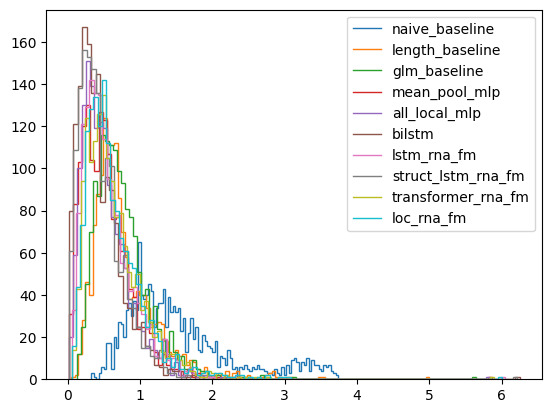

In [683]:
for model in MODEL_ORDER:
    hist, bin_edges = np.histogram(eval_results[model]['wasserstein_scores'], bins=100)
    plt.stairs(hist, bin_edges, label=model)

plt.legend()

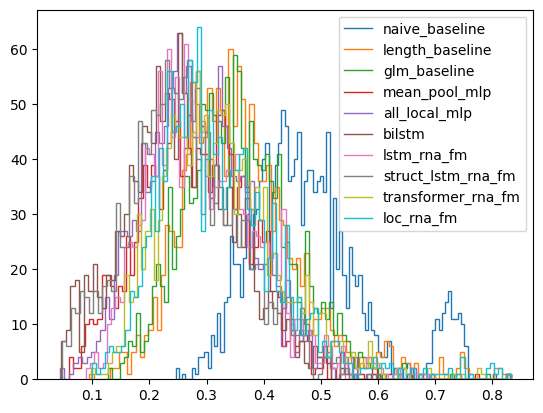

In [ ]:
for model in MODEL_ORDER:
    hist, bin_edges = np.histogram(eval_results[model]['js_scores'], bins=100)
    plt.stairs(hist, bin_edges, label=model)

plt.legend()

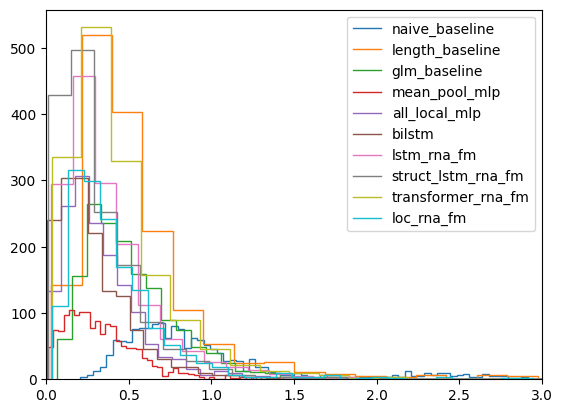

In [687]:
for model in MODEL_ORDER:
    hist, bin_edges = np.histogram(eval_results[model]['kl_scores'], bins=100)
    plt.stairs(hist, bin_edges, label=model)

plt.xlim(0,3)
plt.legend()

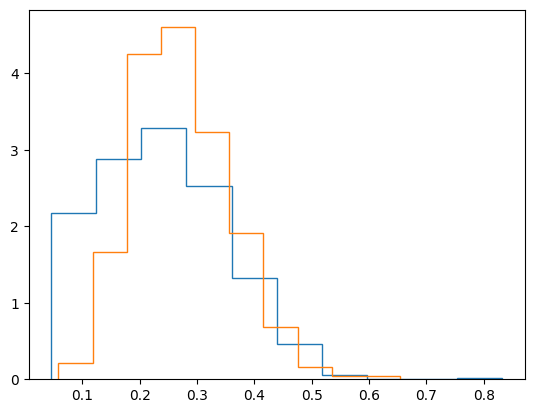

In [694]:
model = 'bilstm'
pred_numpeaks = eval_results[model]['pred_numpeaks']
target_numpeaks = eval_results[model]['target_numpeaks']
    
hist, bin_edges = np.histogram(eval_results[model]['js_scores'][pred_numpeaks == target_numpeaks], density=True)
plt.stairs(hist, bin_edges)

hist, bin_edges = np.histogram(eval_results[model]['js_scores'][pred_numpeaks != target_numpeaks], density=True)
plt.stairs(hist, bin_edges)

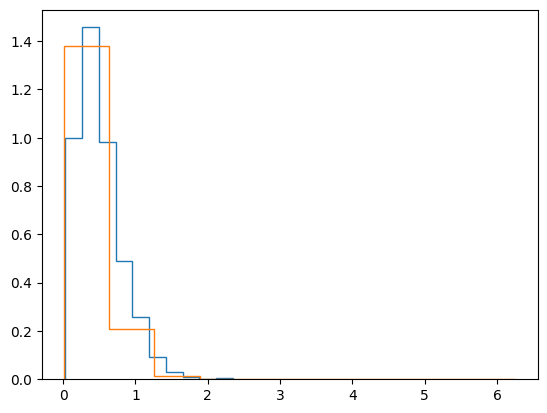

In [693]:
model = 'bilstm'
pred_numpeaks = eval_results[model]['pred_numpeaks']
target_numpeaks = eval_results[model]['target_numpeaks']
    
hist, bin_edges = np.histogram(eval_results[model]['wasserstein_scores'][pred_numpeaks != target_numpeaks], density=True)
plt.stairs(hist, bin_edges)

hist, bin_edges = np.histogram(eval_results[model]['wasserstein_scores'][pred_numpeaks == target_numpeaks], density=True)
plt.stairs(hist, bin_edges)

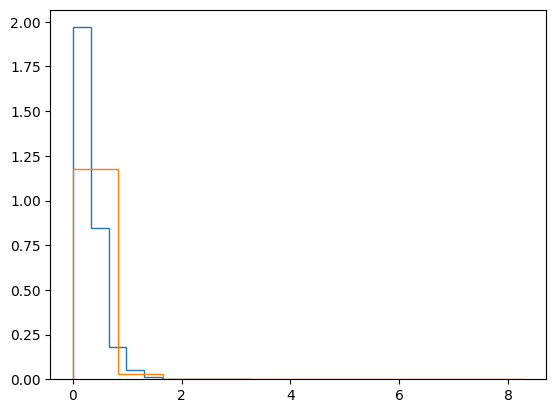

In [695]:
model = 'bilstm'
pred_numpeaks = eval_results[model]['pred_numpeaks']
target_numpeaks = eval_results[model]['target_numpeaks']
    
hist, bin_edges = np.histogram(eval_results[model]['kl_scores'][pred_numpeaks != target_numpeaks], density=True)
plt.stairs(hist, bin_edges)

hist, bin_edges = np.histogram(eval_results[model]['kl_scores'][pred_numpeaks == target_numpeaks], density=True)
plt.stairs(hist, bin_edges)